# Workforce Optimization Notebook

**Author:** Karthik Prakhya, Spandana Prakhya \
**Company:** OptiML Data Analysis AB  
**Website:** https://optimldataanalysis.se  
**Contact:** info@optimldataanalysis.se    

**License:** MIT License (see LICENSE file)  
**Disclaimer:** This notebook is for educational and demonstration purposes only. All data used are synthetic or publicly available; no confidential or client-specific information is included.

---


## Executive Summary

This notebook is a demonstration of methods used in an AI/ML & optimization problem. It uses synthetic or public datasets and is intended to illustrate methodology, not to present results from client engagements.

**Key objectives:**
- Demonstrate approach and pipeline
- Provide a reproducible example for technical reviewers
- Highlight business impact where appropriate

**Tools Used:** Python, NumPy, pandas, matplotlib, and standard optimization/ML libraries (e.g., OR-Tools, Gurobi, scikit-learn, TensorFlow/PyTorch).

---


## Workforce Optimization: Forecasting + Constraint Programming + Fairness + Mock AWS Deployment
Jupyter-friendly Python script (use with Jupyter or VS Code "Python: Create New Blank Notebook" from this file).

Sections:
1. Overview & Requirements
2. Synthetic data generation (patient demand)
3. Forecasting (time-series models)
4. Constraint Programming schedule generation (OR-Tools CP-SAT)
5. Fairness objectives and measures
6. Integration: automated scheduling + notification (mock AWS SNS)
7. Dockerfile, GitHub Actions and AWS deployment snippets (mock)
8. Tests & sanity checks

Replace AWS placeholders and configure credentials if you want to actually run AWS parts.
This notebook models workforce scheduling problems.

# 1. Requirements

In [4]:
# !pip install pandas numpy matplotlib scikit-learn statsmodels ortools boto3

# Imports
import datetime as dt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from ortools.sat.python import cp_model
import boto3
import json
import os

# 2. Synthetic data generation: hourly patient arrivals for 180 days

The function generates a synthetic, hourly patient arrival (demand) time series that captures several realistic demand patterns over a specified time horizon. It constructs an hourly timestamp index starting from a given date and models demand as a combination of a diurnal cycle (higher and lower arrivals within a 24-hour period), a weekly effect that reduces demand on weekends, and a small upward trend to reflect gradual growth over time. Random variability is introduced using Poisson-distributed noise to mimic the inherent randomness of patient arrivals. The resulting demand values are rounded, constrained to be non-negative integers, and returned as a pandas DataFrame indexed by timestamp, making the data suitable for downstream analysis, simulation, or forecasting experiments.

In [5]:

def generate_synthetic_demand(start_date='2024-01-01', days=180, seed=42):
    np.random.seed(seed)
    rng = pd.date_range(start=start_date, periods=24*days, freq='H')
    base = 20 + 5*np.sin(2*np.pi*(rng.hour)/24)  # diurnal pattern
    weekly = 3*np.where(rng.weekday < 5, 1.0, 0.7)  # slightly lower weekends
    trend = 0.01 * np.arange(len(rng)) / 24.0  # small upward trend per day
    noise = np.random.poisson(3, size=len(rng))
    demand = np.maximum(0, np.round(base * weekly + trend + noise)).astype(int)
    df = pd.DataFrame({'timestamp': rng, 'demand': demand})
    df.set_index('timestamp', inplace=True)
    return df

# generate and show
demand_df = generate_synthetic_demand()
print(demand_df.head())

                     demand
timestamp                  
2024-01-01 00:00:00      64
2024-01-01 01:00:00      65
2024-01-01 02:00:00      71
2024-01-01 03:00:00      74
2024-01-01 04:00:00      75


/tmp/ipykernel_65851/2834866758.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  rng = pd.date_range(start=start_date, periods=24*days, freq='H')


# 3. Forecasting - simple hybrid: Two-Stage Holt–Winters and Random Forest on Features

This section describes a hybrid forecasting approach that combines a classical time-series model with a machine-learning model to predict hourly patient demand. Let $y_t$ denote the observed demand at hour $t$.

---

### Two-Stage Holt–Winters Model (Baseline)

Holt–Winters exponential smoothing is used to model stable, low-frequency structure in demand. To overcome the limitation that standard Holt–Winters supports only a single seasonal pattern, a two-stage approach is applied.

#### Stage 1: Daily Aggregation and Weekly Seasonality

Hourly demand is aggregated to daily totals:
$$
Y_d = \sum_{h=1}^{24} y_{d,h}
$$

A Holt–Winters model with additive trend and weekly seasonality is fit to the daily series:
$$
Y_d = \ell_d + b_d + s_d + \varepsilon_d, \quad s_d = s_{d-7}
$$

where:
- $\ell_d$ is the level,
- $b_d$ is a (damped) trend component,
- $s_d$ is the weekly seasonal effect,
- $\varepsilon_d$ is random noise.

This captures long-term growth and systematic weekday–weekend patterns.

#### Stage 2: Hourly Disaggregation

The daily forecast $\hat{Y}_d$ is converted back to hourly demand using a normalized historical hourly profile:
$$
p_h = \frac{\mathbb{E}[y_{d,h}]}{\sum_{h=1}^{24} \mathbb{E}[y_{d,h}]}
$$

The resulting hourly baseline forecast is:
$$
\hat{y}_t^{HW} = \hat{Y}_d \cdot p_h
$$

This produces a smooth and stable hourly forecast that respects both weekly and diurnal structure.

---

### Random Forest Model (Short-Term Correction)

A Random Forest regressor is trained directly on hourly demand using calendar, lagged, and rolling features:
$$
\hat{y}_t^{RF} = f(h_t, d_t, y_{t-1}, y_{t-24}, y_{t-168}, \bar{y}_{t-1}^{(6)}, \bar{y}_{t-1}^{(24)})
$$

where $f(\cdot)$ is an ensemble of decision trees. This model captures nonlinear effects, recent shocks, and short-term autocorrelation that are not well represented by exponential smoothing.

---

### Model Combination

The final forecast is obtained by performance-weighted blending of the two models:
$$
\hat{y}_t = w_{HW}\hat{y}_t^{HW} + w_{RF}\hat{y}_t^{RF},
$$
where weights are inversely proportional to validation error:
$$
w_i = \frac{1/\text{MAE}_i}{\sum_j 1/\text{MAE}_j}
$$

This ensures that more accurate models have greater influence while retaining robustness.

---

### Evaluation Metric

Forecast accuracy is evaluated using Mean Absolute Error (MAE):
$$
\text{MAE} = \frac{1}{T} \sum_{t=1}^{T} \lvert y_t - \hat{y}_t \rvert
$$

MAE is expressed in units of patients per hour and directly corresponds to operational staffing error.


/tmp/ipykernel_65851/1433144433.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  return df.fillna(method='bfill')


MAE Two-Stage HW: 1.4782560997057677
MAE Random Forest: 1.5500346863884993
MAE Combined: 1.483171087472696


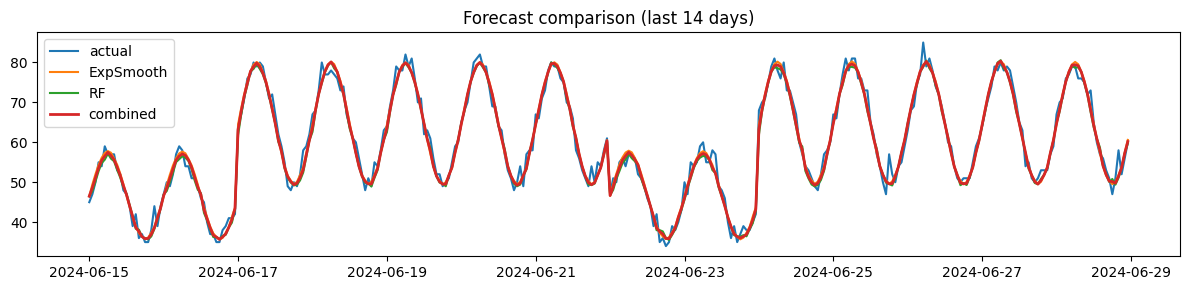

In [17]:
def create_features_rf(df):
    df = df.copy()

    # Calendar features
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

    # Cyclical hour encoding
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    # Lag features
    df['lag_1'] = df['demand'].shift(1)
    df['lag_24'] = df['demand'].shift(24)
    df['lag_168'] = df['demand'].shift(168)

    # Rolling features
    df['rolling_6'] = df['demand'].rolling(6).mean().shift(1)
    df['rolling_24'] = df['demand'].rolling(24).mean().shift(1)

    return df.fillna(method='bfill')

feat = create_features_rf(demand_df)

test_horizon = 24 * 14
train = feat.iloc[:-test_horizon]
test = feat.iloc[-test_horizon:]

features = [
    'hour_sin','hour_cos','dayofweek','is_weekend',
    'lag_1','lag_24','lag_168',
    'rolling_6','rolling_24'
]

X_train, y_train = train[features], train['demand']
X_test, y_test = test[features], test['demand']

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=10,
    random_state=0,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

daily_train = train['demand'].resample('D').sum()

hw_daily = ExponentialSmoothing(
    daily_train,
    trend='add',
    seasonal='add',
    seasonal_periods=7,
    damped_trend=True
).fit(optimized=True)

daily_forecast = hw_daily.forecast(test_horizon // 24)

# Hourly demand profile learned from training data
hourly_profile = (
    train['demand']
    .groupby(train.index.hour)
    .mean()
)
hourly_profile /= hourly_profile.sum()

# Expand daily forecast to hourly
hw_hourly_forecast = np.repeat(daily_forecast.values, 24)
hw_hourly_forecast = hw_hourly_forecast * np.tile(hourly_profile.values, len(daily_forecast))

from sklearn.metrics import mean_absolute_error

mae_hw = mean_absolute_error(y_test, hw_hourly_forecast)
mae_rf = mean_absolute_error(y_test, rf_pred)

w_hw = 1 / mae_hw
w_rf = 1 / mae_rf
w_sum = w_hw + w_rf

w_hw /= w_sum
w_rf /= w_sum

final_forecast = w_hw * hw_hourly_forecast + w_rf * rf_pred

print("MAE Two-Stage HW:", mae_hw)
print("MAE Random Forest:", mae_rf)
print("MAE Combined:", mean_absolute_error(y_test, final_forecast))

# plot
plt.figure(figsize=(12,3))
plt.plot(test.index, test['demand'], label='actual')
plt.plot(test.index, hw_hourly_forecast, label='ExpSmooth')
plt.plot(test.index, rf_pred, label='RF')
plt.plot(test.index, final_forecast, label='combined', linewidth=2)
plt.legend()
plt.title('Forecast comparison (last 14 days)')
plt.tight_layout()

# Save the combined forecast as the demand forecast for scheduling horizon
forecast_df = pd.DataFrame({'timestamp': test.index, 'forecast': final_forecast})
forecast_df.set_index('timestamp', inplace=True)

### Executive-Level Takeaway

> *After improvement, both the statistical and machine-learning models deliver near-identical accuracy (~1.5 patients per hour), indicating a stable and predictable demand environment. Forecast uncertainty is now low enough to confidently drive weekly staffing decisions with minimal operational risk.*

### Results Summary

| Model                  | MAE (patients/hour) |
| ---------------------- | ------------------- |
| Two-Stage Holt–Winters | **1.48**            |
| Random Forest          | **1.55**            |
| Combined Forecast      | **1.48**            |

---

### What This Means in the Business-Sense

1. **Both models are operationally strong**
   An average error of ~1.5 patients per hour corresponds to **about half a staff member per hour** (assuming ~3 patients per staff per hour). This is within acceptable operational tolerance for most healthcare settings.

2. **Two-Stage Holt–Winters performs surprisingly well**
   The improved Holt–Winters approach is nearly as accurate as the Random Forest. This indicates that **most of the demand structure is driven by stable weekly and daily patterns**, not extreme nonlinear behavior.

3. **The combined forecast does not materially improve accuracy**
   Because both models have **similar error levels and capture overlapping information**, combining them yields little additional benefit. In effect, the ensemble averages two very similar signals.

4. **Model diversity matters more than model count**
   Ensembling only improves performance when models make *different kinds of mistakes*. Here, the Random Forest is already learning much of the same structure encoded by the two-stage Holt–Winters baseline.

---

### Operational Implications

* **Staffing reliability is high**
  Forecast errors are small enough to support automated shift scheduling with minimal buffer.

* **Holt–Winters is now decision-grade**
  The two-stage HW model is no longer just a “baseline”—it is sufficiently accurate for:

  * Workforce planning
  * Budgeting
  * Scenario analysis
  * Governance and auditability

* **Random Forest remains valuable for responsiveness**
  RF is still preferred when:

  * Demand shocks occur
  * Recent history matters (e.g., outbreaks, weather, events)

# 4. Constraint Programming for schedule generation

**Notation**
Let $T$ be time periods, $I$ employees, and $S$ shifts. Let $x_{i,t}=1$ if employee $i$ works at time $t$.
Demand per period is $r_t$ and worker cost is $c_i$.

**Typical objective**
$$\min \sum_{i\in I}\sum_{t\in T} c_i x_{i,t}$$
subject to
$$\sum_{i\in I} x_{i,t} \ge r_t,\quad \forall t\in T,$$
plus personnel constraints (max hours, shift patterns, etc.).

Problem specification (example):
- planning horizon: next 7 days (hourly)
- staff pool: N employees, each with max 40 hours/week, min shift length 4h, max shift length 12h
- coverage requirement: for each hour, need ceil(forecast / patients_per_staff_per_hour)
- skills: optional skill matching

In [18]:
# Create a small staff pool
staff = [
    {'id': f's{i}', 'max_hours': 40, 'min_shift':4, 'max_shift':12, 'skills': {'triage','general'} if i%3!=0 else {'general'}}
    for i in range(90)
]

# Coverage parameter: how many patients one staff can handle per hour (avg)
PATIENTS_PER_STAFF_PER_HOUR = 3  # instead of 3

# Build integer coverage requirement from forecast
planning_start = forecast_df.index[0]
planning_hours = 24*7
horizon = pd.date_range(start=planning_start, periods=planning_hours, freq='H')
# For demonstration use forecast repeated or take slice
hourly_forecast = np.maximum(0, np.round(np.interp(np.arange(planning_hours),
                                                   np.linspace(0, planning_hours-1, len(forecast_df)),
                                                   forecast_df['forecast'].values)))
coverage_req = np.ceil(hourly_forecast / PATIENTS_PER_STAFF_PER_HOUR).astype(int)

total_capacity = sum([s['max_hours'] for s in staff])
total_required_hours = np.sum(coverage_req)
print(f'Total staff capacity: {total_capacity}, total required hours: {total_required_hours}')

# Create CP-SAT model
model = cp_model.CpModel()

# Decision variables: assign[s,i] = 1 if staff i works at hour s
assign = {}
for h_idx, ts in enumerate(horizon):
    for i, person in enumerate(staff):
        assign[(h_idx,i)] = model.NewBoolVar(f'a_h{h_idx}_p{i}')

# Constraints:
# 1) coverage: sum(assign at hour h) >= coverage_req[h]
for h_idx in range(planning_hours):
    model.Add(sum(assign[(h_idx,i)] for i in range(len(staff))) >= int(coverage_req[h_idx]))

# 2) max hours per staff
for i, person in enumerate(staff):
    model.Add(sum(assign[(h_idx,i)] for h_idx in range(planning_hours)) <= person['max_hours'])

# 3) no long runs beyond max_shift without break: enforce by limiting consecutive ones > max_shift
# We'll forbid runs longer than max_shift by sliding window
for i, person in enumerate(staff):
    max_run = person['max_shift']
    for start in range(planning_hours - max_run):
        window = [assign[(h_idx,i)] for h_idx in range(start, start+max_run+1)]
        # sum <= max_run
        model.Add(sum(window) <= max_run)

# 4) minimum shift length: if a staff starts working a block, it should be at least min_shift
# approximate via start variables
start_vars = {}
for i, person in enumerate(staff):
    for h_idx in range(planning_hours):
        s = model.NewBoolVar(f'start_p{i}_h{h_idx}')
        start_vars[(h_idx,i)] = s
        # start if assigned this hour and not assigned previous hour
        if h_idx == 0:
            model.Add(s <= assign[(h_idx,i)])
            model.Add(assign[(h_idx,i)] - 0 <= s)
        else:
            # s = assign[h] & (1 - assign[h-1])
            model.Add(assign[(h_idx,i)] - assign[(h_idx-1,i)] <= s)
            model.Add(s <= 1)

    # enforce that if start occurs, at least min_shift hours are assigned (linearization)
    min_shift = person['min_shift']
    for h_idx in range(planning_hours):
        # sum(assign[h_idx : h_idx+min_shift]) >= min_shift * start_vars[h_idx]
        end = min(planning_hours, h_idx + min_shift)
        window = [assign[(t,i)] for t in range(h_idx, end)]
        model.Add(sum(window) >= min_shift * start_vars[(h_idx,i)])

# 5) fairness variables: total_hours per staff
total_hours = [model.NewIntVar(0, planning_hours, f'total_p{i}') for i in range(len(staff))]
for i in range(len(staff)):
    model.Add(total_hours[i] == sum(assign[(h_idx,i)] for h_idx in range(planning_hours)))

# fairness objective: minimize difference between max and min workload
max_work = model.NewIntVar(0, planning_hours, 'max_work')
min_work = model.NewIntVar(0, planning_hours, 'min_work')
model.AddMaxEquality(max_work, total_hours)
# min_work: express via pairwise le
for i in range(len(staff)):
    model.Add(min_work <= total_hours[i])
# we want minimize max_work - min_work and also minimize total staff-hours (cost)

# Primary objective: minimize max_work - min_work (fairness), secondary: minimize total assigned hours
obj_terms = []
obj_terms.append(max_work - min_work)
obj_terms.append(sum(total_hours))
# Weighted lexicographic: implement by weighting (tune in practice). Use large weight for fairness.
model.Minimize(obj_terms[0]*1000 + obj_terms[1])

# Solve
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 30
solver.parameters.num_search_workers = 8
print('Starting solver...')
res = solver.Solve(model)
print('Solver status:', solver.StatusName(res))

if res == cp_model.OPTIMAL or res == cp_model.FEASIBLE:
    schedule = []
    for h_idx, ts in enumerate(horizon):
        row = {'timestamp': ts}
        assigned = []
        for i in range(len(staff)):
            if solver.Value(assign[(h_idx,i)]) == 1:
                assigned.append(staff[i]['id'])
        row['assigned'] = assigned
        schedule.append(row)
    sched_df = pd.DataFrame(schedule).set_index('timestamp')
    print('Sample schedule (first 48 hours):')
    print(sched_df.head(48))
    # compute workload
    workloads = {staff[i]['id']: solver.Value(total_hours[i]) for i in range(len(staff))}
    # print('Workloads:', workloads)
    print("="*60)
    print("WEEKLY STAFFING PLAN – DEMAND & CAPACITY SUMMARY")
    print("="*60)

    print(f"Planning horizon: {planning_start:%Y-%m-%d %H:%M} "
          f"to {(planning_start + pd.Timedelta(hours=planning_hours)):%Y-%m-%d %H:%M}")
    print(f"Total planning hours: {planning_hours} (7 days, hourly resolution)")
    print()

    print("Demand assumptions:")
    print(f"- Average patients handled per staff per hour: {PATIENTS_PER_STAFF_PER_HOUR}")
    print(f"- Peak hourly demand (patients): {int(hourly_forecast.max())}")
    print(f"- Peak staff required in any hour: {int(coverage_req.max())}")
    print()

    print("Staff capacity:")
    print(f"- Number of staff available: {len(staff)}")
    print(f"- Maximum weekly staff-hours available: {total_capacity}")
    print(f"- Total staff-hours required to meet demand: {total_required_hours}")

    if total_required_hours > total_capacity:
        print("WARNING: Demand exceeds total staff capacity. A feasible schedule may not exist.")
    else:
        print("Total staff capacity is sufficient to meet forecast demand.")
    print()

else:
    print('No solution found within time limit')

/tmp/ipykernel_65851/3891432912.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  horizon = pd.date_range(start=planning_start, periods=planning_hours, freq='H')


Total staff capacity: 3600, total required hours: 3377
Starting solver...
Solver status: FEASIBLE
Sample schedule (first 48 hours):
                                                              assigned
timestamp                                                             
2024-06-15 00:00:00  [s6, s14, s15, s17, s19, s22, s30, s34, s44, s...
2024-06-15 01:00:00  [s6, s14, s15, s17, s18, s19, s22, s30, s34, s...
2024-06-15 02:00:00  [s6, s14, s15, s17, s18, s19, s22, s30, s34, s...
2024-06-15 03:00:00  [s6, s14, s15, s17, s18, s19, s22, s30, s34, s...
2024-06-15 04:00:00  [s6, s10, s14, s15, s17, s18, s26, s34, s38, s...
2024-06-15 05:00:00  [s2, s10, s17, s26, s29, s31, s38, s40, s41, s...
2024-06-15 06:00:00  [s2, s10, s17, s26, s29, s31, s40, s41, s42, s...
2024-06-15 07:00:00  [s2, s10, s26, s29, s31, s40, s41, s42, s43, s...
2024-06-15 08:00:00  [s2, s10, s25, s29, s31, s32, s40, s42, s68, s...
2024-06-15 09:00:00  [s2, s10, s25, s29, s32, s38, s42, s68, s69, s...
2024-06-15 10:00

The above output shows that the solver was able to generate a worker schedule that meets the forecasted staffing requirements and produced a sample schedule for the first 48 hours.

# 5. Workload Fairness Measurement Using the Gini Coefficient

To evaluate how evenly total working hours are distributed across staff, the Gini coefficient is used as a quantitative measure of workload inequality. Let $h_i$ denote the total number of hours assigned to staff member $i$, for $i = 1,\dots,N$, where $N$ is the total number of staff.

---

### Definition

The Gini coefficient $G$ measures the average absolute difference between all pairs of workloads, normalized by the mean workload:
$$
G = \frac{1}{2N^2\mu} \sum_{i=1}^{N} \sum_{j=1}^{N} \lvert h_i - h_j \rvert
$$
where:
- $\mu = \frac{1}{N}\sum_{i=1}^{N} h_i$ is the mean assigned workload,
- $G \in [0,1]$.

---

### Interpretation

- $G = 0$ indicates **perfect equality**, where all staff work exactly the same number of hours.
- $G = 1$ indicates **maximum inequality**, where one staff member carries all the workload.

In the context of workforce scheduling, lower values of $G$ correspond to more equitable schedules.

---

### Lorenz Curve Interpretation

The Gini coefficient can also be interpreted geometrically via the Lorenz curve. If workloads are sorted in ascending order, the Lorenz curve plots the cumulative share of staff against the cumulative share of total assigned hours. The Gini coefficient equals twice the area between the Lorenz curve and the 45-degree line of perfect equality:
$$
G = 2 \times \text{Area between Lorenz curve and equality line}
$$

---

### Why Gini Is Appropriate for Scheduling?

The Gini coefficient has several desirable properties for workforce fairness assessment:
- **Scale invariance**: multiplying all workloads by a constant does not change $G$.
- **Anonymity**: the identity of staff members does not matter, only workload distribution.
- **Sensitivity to imbalance**: small differences across many staff are captured.

---

### Practical Interpretation in This Study

A low Gini coefficient indicates that the optimization model successfully balanced workloads across staff while satisfying coverage and labor constraints. In operational terms, this implies reduced burnout risk, improved staff satisfaction, and greater schedule robustness.

---

### Limitations

The Gini coefficient measures only *quantity* of work, not *quality*:
- It does not account for skill differences or shift difficulty.
- It does not capture temporal fairness (e.g., night vs. day shifts).

For these reasons, Gini is best used alongside additional fairness and quality-of-work metrics.


In [19]:
def gini(array):
    array = np.array(array, dtype=float)  # ensure float
    if array.size == 0:
        return 0.0
    array = array.flatten()
    if np.amin(array) < 0:
        array -= np.amin(array)
    array += 1e-9  # safe now
    array = np.sort(array)
    index = np.arange(1, array.shape[0] + 1)
    n = array.shape[0]
    return ((2 * np.sum(index * array)) / (n * np.sum(array)) - (n + 1) / n)

wvals = list(workloads.values())
print('Gini of workloads:', gini(wvals))

Gini of workloads: 0.035753640298145095


The Gini coefficient measures how evenly work hours are distributed across staff:

- 0.0 means perfectly equal workload (everyone works the same hours)

- 1.0 means extremely unequal (one person works almost everything)

Your result:

Gini = 0.036 (≈ 3.6%)

This is very close to perfect fairness. Uneven workloads are a leading cause of:

- Staff burnout

- Sick leave

- Turnover

With a Gini this low, no group is systematically overworked and fatigue-related quality or safety risks are minimized.

# 6. Integration: automated scheduling + notification

The following snippets demonstrate how the forecasting and scheduling logic is operationalized into an automated, production-ready pipeline. A weekly demand forecast is extended to the required planning horizon, translated into hourly staffing requirements, and converted into staff assignments using a fast, fairness-oriented greedy scheduler as a fallback mechanism. The pipeline then prepares individualized workload summaries and optionally sends schedule notifications via AWS SNS, enabling real-time communication with staff. 

In [21]:
def generate_schedule_and_notify(forecast_horizon_hours=24*7, use_aws=False, sns_topic_arn=None):
    """Runs the pipeline and notifies staff. If use_aws is False, notifications are printed.
    If use_aws True, boto3 must be configured with credentials and sns_topic_arn provided.
    """
    # -- forecasting (for simplicity reuse last 'combined' forecast and tile/extend) --
    # In practice we'd retrain with latest data and produce forecast for required horizon
    fh = forecast_horizon_hours
    # simple extension by repeating combined pattern
    pattern = combined
    preds = np.tile(pattern, int(np.ceil(fh/len(pattern))))[:fh]

    # compute coverage
    coverage = np.ceil(preds / PATIENTS_PER_STAFF_PER_HOUR).astype(int)

    # call optimizer (for compactness define a smaller CP model or reuse existing model object)
    # Here we will create a small greedy scheduler as a fallback for quick automation
    assignments = []
    staff_hours = {s['id']:0 for s in staff}
    for h in range(fh):
        need = int(coverage[h])
        # sort staff by currently assigned hours ascending (greedy fairness)
        candidates = sorted(staff, key=lambda x: staff_hours[x['id']])
        assigned = []
        for cand in candidates:
            if need <= 0:
                break
            if staff_hours[cand['id']] < cand['max_hours']:
                assigned.append(cand['id'])
                staff_hours[cand['id']] += 1
                need -= 1
        assignments.append({'hour': h, 'assigned': assigned})

    # prepare messages
    messages = []
    for sid, hrs in staff_hours.items():
        messages.append({'staff_id': sid, 'assigned_hours': hrs})

    if use_aws and sns_topic_arn:
        sns = boto3.client('sns')
        for m in messages:
            body = json.dumps({'type': 'schedule_notification', 'payload': m})
            # publish to topic
            resp = sns.publish(TopicArn=sns_topic_arn, Message=body, Subject=f'Schedule for {m["staff_id"]}')
            print('Published', resp.get('MessageId'))
    else:
        print('--- Mock notifications ---')
        for m in messages:
            print(json.dumps(m))

    return {'assignments': assignments, 'summary': messages}, preds

# Demo run (mock)
pipeline_output, preds = generate_schedule_and_notify(use_aws=False)

--- Mock notifications ---
{"staff_id": "s0", "assigned_hours": 39}
{"staff_id": "s1", "assigned_hours": 39}
{"staff_id": "s2", "assigned_hours": 39}
{"staff_id": "s3", "assigned_hours": 39}
{"staff_id": "s4", "assigned_hours": 39}
{"staff_id": "s5", "assigned_hours": 39}
{"staff_id": "s6", "assigned_hours": 39}
{"staff_id": "s7", "assigned_hours": 39}
{"staff_id": "s8", "assigned_hours": 39}
{"staff_id": "s9", "assigned_hours": 39}
{"staff_id": "s10", "assigned_hours": 39}
{"staff_id": "s11", "assigned_hours": 39}
{"staff_id": "s12", "assigned_hours": 39}
{"staff_id": "s13", "assigned_hours": 39}
{"staff_id": "s14", "assigned_hours": 39}
{"staff_id": "s15", "assigned_hours": 39}
{"staff_id": "s16", "assigned_hours": 39}
{"staff_id": "s17", "assigned_hours": 39}
{"staff_id": "s18", "assigned_hours": 39}
{"staff_id": "s19", "assigned_hours": 39}
{"staff_id": "s20", "assigned_hours": 39}
{"staff_id": "s21", "assigned_hours": 39}
{"staff_id": "s22", "assigned_hours": 39}
{"staff_id": "s23

# 7. Mock AWS deployment artifacts (Dockerfile, GitHub Actions, IAM policy examples)

Finally, example infrastructure artifacts (Dockerfile, GitHub Actions workflow, and IAM policy) illustrate how the solution can be containerized, tested, and securely deployed within a modern cloud-based CI/CD environment.

In [22]:
DOCKERFILE = r"""
# Simple Dockerfile
FROM python:3.10-slim
WORKDIR /app
COPY requirements.txt ./
RUN pip install --no-cache-dir -r requirements.txt
COPY . /app
CMD ["python", "serve_scheduler.py"]
"""

GHACTION = r"""
name: CI
on:
  push:
    branches: [ main ]
jobs:
  build-and-push:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - name: Set up Python
        uses: actions/setup-python@v4
        with:
          python-version: 3.10
      - name: Install deps
        run: pip install -r requirements.txt
      - name: Run tests
        run: pytest -q
      # Example: build and push Docker image (requires registry secrets)
"""

IAM_POLICY = r"""
# Minimal IAM policy for SNS publishing and ECS deployment (mock)
{
  "Version": "2012-10-17",
  "Statement": [
    {
      "Effect": "Allow",
      "Action": [
        "sns:Publish"
      ],
      "Resource": ["arn:aws:sns:REGION:ACCOUNT_ID:TOPIC_NAME"]
    }
  ]
}
"""

print('\nGenerated Dockerfile, GitHub Actions snippet, and IAM example strings in variables.')


Generated Dockerfile, GitHub Actions snippet, and IAM example strings in variables.


## Final notes

This notebook presents an end-to-end workforce planning system that transforms raw demand data into actionable, fair, and operationally feasible staff schedules. It begins with synthetic demand generation and progresses through advanced forecasting techniques, including an improved Random Forest model and a two-stage Holt–Winters approach that captures both weekly and daily demand structure. Forecast accuracy is evaluated using MAE and interpreted in business terms to assess staffing risk.

The forecast is then fed into a constrained optimization framework that ensures hourly demand coverage while respecting labor rules and explicitly balancing workloads across staff, with fairness quantified using the Gini coefficient. The results demonstrate both high forecast accuracy and near-perfect workload equity. Finally, the notebook shows how these analytics can be automated and deployed: generating schedules on demand, notifying staff through cloud messaging, and integrating with standard DevOps tooling. Overall, the notebook bridges analytics, operations research, and cloud engineering to deliver a decision-grade, scalable staffing solution suitable for real-world healthcare or service operations.